# Lab 067 · LoCalPFN: retrieve a context, then adapt the inference rule

[Lesson](../lessons/0067-local-pfn-retrieval-finetuning.html) · [Reference](../reference/0067-local-pfn-retrieval-finetuning.html) · [Measured evidence](_verify_l067_v2_results.json) · [Reproduction](l067-reproduction.md)

**Skill:** implement five live functions that retrieve, construct, normalize, supervise and select local episodes around a complete pretrained TabPFN. **PROVIDED** cells expose the model and training loop. **TODO** cells contain your live blanks; **CHECK** validates their behavior against independent source; **EXIT** saves an actual measured interpretation.

Default CPU experiment: all 768 diabetes rows, stratified 80/10/10 split seed 7, paper dynamic k=247, two contexts with 16 queries each,30 updates, validation selection between 0 and 30. Two predeclared learning rates .01 and 1e-5 probe the paper/released-CLI discrepancy. Five inference arms share held-out rows. Full 25.8M historical model download≈103MB. The three-dataset author panel is larger than the default notebook. Original pretraining and 95-task 10-fold paper benchmark are NOT_RUN; this run is INCOMPARABLE to paper-result reproduction.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Localize the evidence before adapting the inference rule

<a href="../lessons/0066-tabicl-column-row-attention.html">TabICL</a> reorganized computation inside the pretrained model. LoCalPFN changes what surrounds it: retrieve a query-specific context, normalize that local problem, then run a complete PFN. Optional fine-tuning changes the weights as well. Keeping those interventions separate connects this lesson back to <a href="../lessons/0052-tabr-retrieval.html">TabR</a> while avoiding the false impression that all retrieval models use the same geometry.

**Connecting the ideas.** Local context is useful only relative to a distance rule. The global training-fitted scale defines who is close; the second, local scale defines what the pretrained PFN receives. Swapping these roles changes the whole composed predictor.

## The skill: distinguish a better context from a better inference rule

An in-context predictor receives labeled rows and predicts the label of another row. Its parameters may remain fixed, yet its answer changes when you change those examples. Fine-tuning changes the parameters themselves. By the end of this lesson you should be able to implement both interventions, identify exactly where labels enter, and explain why a faster training episode approximates a different neighborhood from the one used at inference.

This distinction matters for our relational mission. A neighborhood retrieved from a customer table, an event history or a graph is an information policy. The neural network consuming that neighborhood is a separate learned rule. If a system improves, we need to know whether the useful change was eligible information, its representation, the learned rule, or the evaluation boundary. “We added retrieval” is too coarse an explanation.

The central source is Thomas et al., [Retrieval & Fine-Tuning for In-Context Tabular Models, final NeurIPS 2024 paper](https://papers.nips.cc/paper_files/paper/2024/file/c40daf14d7a6469e65116507c21faeb7-Paper-Conference.pdf). Read Sections 2.1–2.4, 4 and Appendix A.2/A.5. The final paper adds a runtime study; its Table 9 corresponds to Table 8 in the earlier arXiv version. The [official implementation](https://github.com/layer6ai-labs/LoCalPFN/tree/ff8803c57cd277380b2444f0f5ed4856b46f47f5) is pinned independently. This is the original whole-row TabPFN v1 backbone. The feature-token v2 model from Lesson 064 and the TabICL model from Lesson 066 are different models and do not silently replace it.

### Retrieve before reading

Without looking back, explain why a query label must be withheld even when its feature vector is present. Then distinguish a train-fitted normalizer from one fitted on the current query batch. Finally, predict whether changing the training examples can alter a frozen model's output. These are the ingredients we now combine; an answer about “no gradients” alone does not establish no leakage.

## Why a local context can make a frozen model more expressive

Write the training memory as D = {(xᵢ, yᵢ)} for i = 1,…,N. A feature vector xᵢ has F columns; yᵢ is an integer in {0,…,K−1}. A context C is the subset of these labeled examples supplied to the model. The pretrained function fθ receives C and the query features q and returns K real-valued scores, called logits. Softmax converts them into probabilities: p(y=c | q,C) = exp(fθ(q,C)ᶜ) / Σⱼ exp(fθ(q,C)ʲ). θ names all neural weights. In-context prediction holds θ fixed. The name “locally calibrated PFN” describes this adaptation method; it is not a guarantee of probability calibration, and the paper’s AUC benchmark is not a calibration-curve evaluation.

The global strategy uses the same C for every q. The local strategy sets C(q) to q's k nearest eligible memory rows. Even with the same θ, the composed mapping q → C(q) → fθ(q,C(q)) is a different predictor. As q crosses a neighborhood boundary, the rows entering the computation can change. This can represent local variation that a single shared context fails to use. It does not make a nearest-neighbor vote: the transformer still processes every retrieved row jointly and learns how their features and labels inform q.

The concentric-circle experiment in paper Figure 1 holds the training count at 1,000 and increases the number of class-alternating rings. It asks about target complexity at fixed size. The three real-data curves in Figure 2 vary memory size and context length; they ask whether a fixed context budget can use more candidate data. These are different interventions. More memory may improve the candidate neighborhood even when k stays fixed. Neither experiment proves that distance is a good similarity measure for every table.

There is also an instructive limit. If k=N, local retrieval returns every training row. Given identical preprocessing, class axes and weights, reordering that full context leaves the row-permutation-invariant model's answer unchanged, apart from floating-point effects. This is a useful implementation CHECK. At the other extreme, a small k can omit distant but informative cases or entire classes. The paper's Figure 9 shows train/test loss gaps consistent with increased overfitting for some small neighborhoods. Locality changes the bias and variance of the whole system; it is not a monotonic performance guarantee.

## Two normalizations, two jobs

The official numeric data path first fits StandardScaler on the outer training split, using a population standard deviation, then clips transformed coordinates to [−10,10]. That representation defines Euclidean retrieval. Validation and test rows are transformed using the same stored training mean and scale. For numeric-only datasets, the paper's one-hot option leaves the representation unchanged. The measured lab excludes categorical datasets; it therefore does not test the claimed gain from one-hot encoding.

Squared Euclidean distance is d²(q,xᵢ) = Σⱼ(qⱼ−xᵢⱼ)² in those transformed coordinates. A feature measured in thousands can dominate one measured in fractions before scaling. Standardization removes that unit choice, but it does not discover relevance. Ten irrelevant standardized columns still contribute ten noise terms. One-hot categories also create a specific geometry: standardized rare categories can contribute large distances. A learned metric would require another training objective and another leakage audit; the paper's default uses fixed features.

Once a neighborhood has been retrieved, the model normalizes again, this time using only that local context. The actual source first pads to 100 coordinates and forms a contiguous sequence-first tensor. The following equations describe the active feature coordinates; the exact reduction layout is discussed immediately below. For each feature, μ is the mean of its C context values and s² = Σᵢ(xᵢ−μ)²/(C−1) is the sample variance. Every context and query value becomes clip((x−μ)/(s+10⁻⁶),−100,100). Then divide by F/100, which is multiplication by 100/F in exact arithmetic. The other coordinates were zero-padded before normalization. This scaling is part of the released pretrained input contract. This second operation makes the PFN see a context-relative problem; it is distinct from deciding who is near the query.

For a one-feature illustration, context values [0,2,4] have mean 2 and sample standard deviation 2. A query value 3 becomes approximately 0.5. If the active model input has F=4 features, that active coordinate is scaled to approximately 12.5. The earlier zero padding does not change this illustrative coordinate’s arithmetic. The order matters: normalization followed by scaling differs from scaling followed by normalization, because the latter largely cancels the scale factor.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Illustrative one-coordinate trace: context [0,2,4], query 3, sample mean 2/std 2, active feature count F=4. Query ≈0.5 after local scaling becomes ≈12.5 after 100/F. The pictured active coordinate is unaffected by initial zero padding; the source pads before its contiguous masked reductions." src="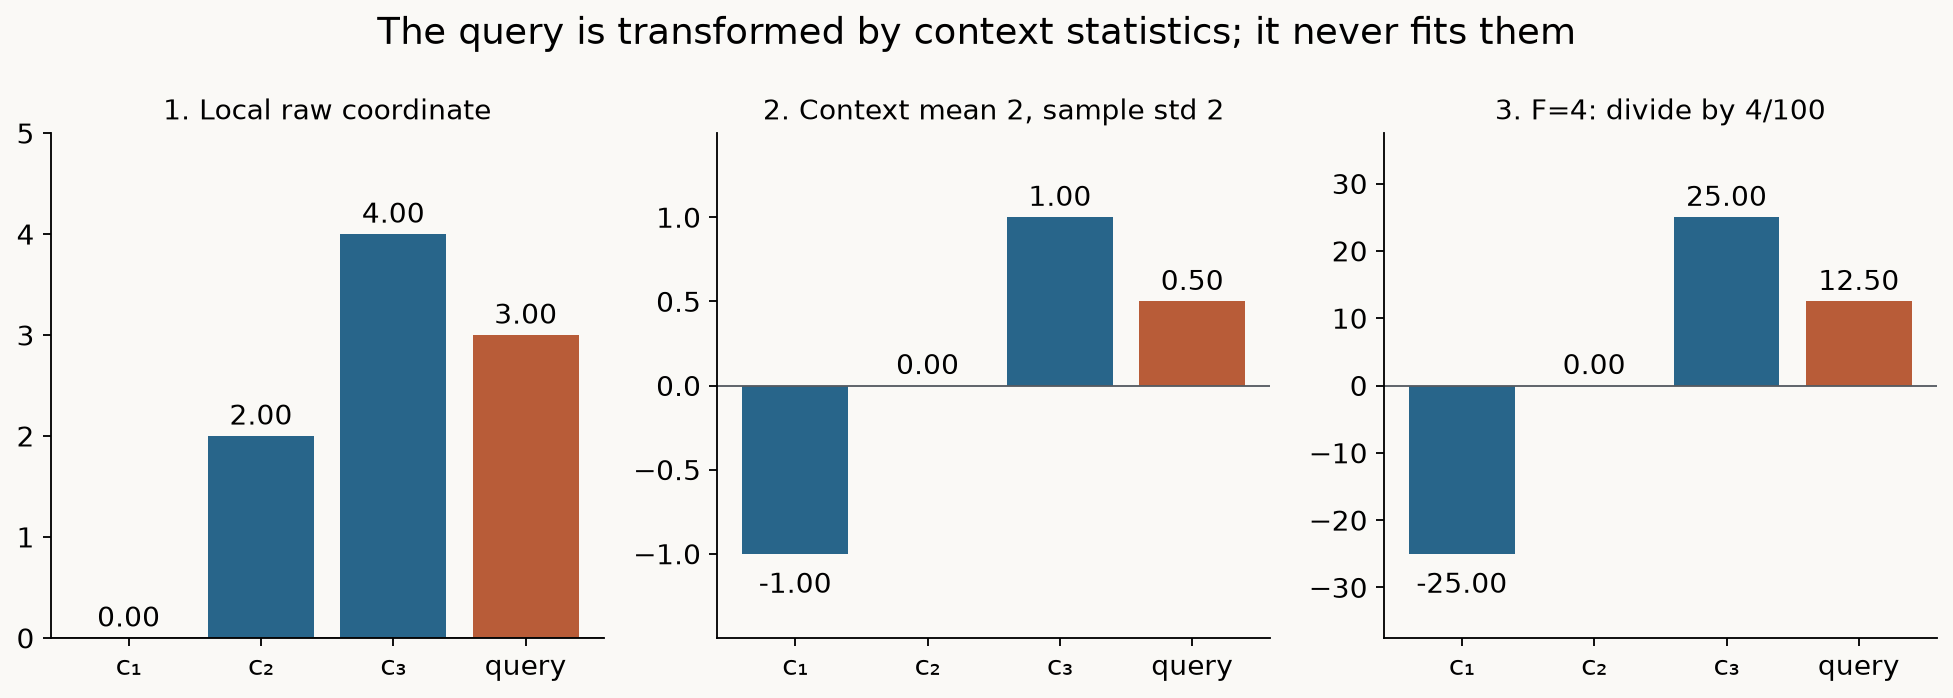" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Illustrative one-coordinate trace: context [0,2,4], query 3, sample mean 2/std 2, active feature count F=4. Query ≈0.5 after local scaling becomes ≈12.5 after 100/F. The pictured active coordinate is unaffected by initial zero padding; the source pads before its contiguous masked reductions. [Full-size figure](figures/l067/normalization-v2.png).

**Connecting the ideas.** The two transforms specify the retrieval and input contracts. Now trace the complete composition: legal memory, nearest records, local normalization, all pretrained layers and the class head. Retrieval chooses evidence; the PFN still performs the conditional inference.

### LoCalPFN: retrieval wraps a complete pretrained network

**Trace before reading:** Does changing the neighbor set require changing the PFN weights?

<div style="max-width:100%;overflow-x:auto">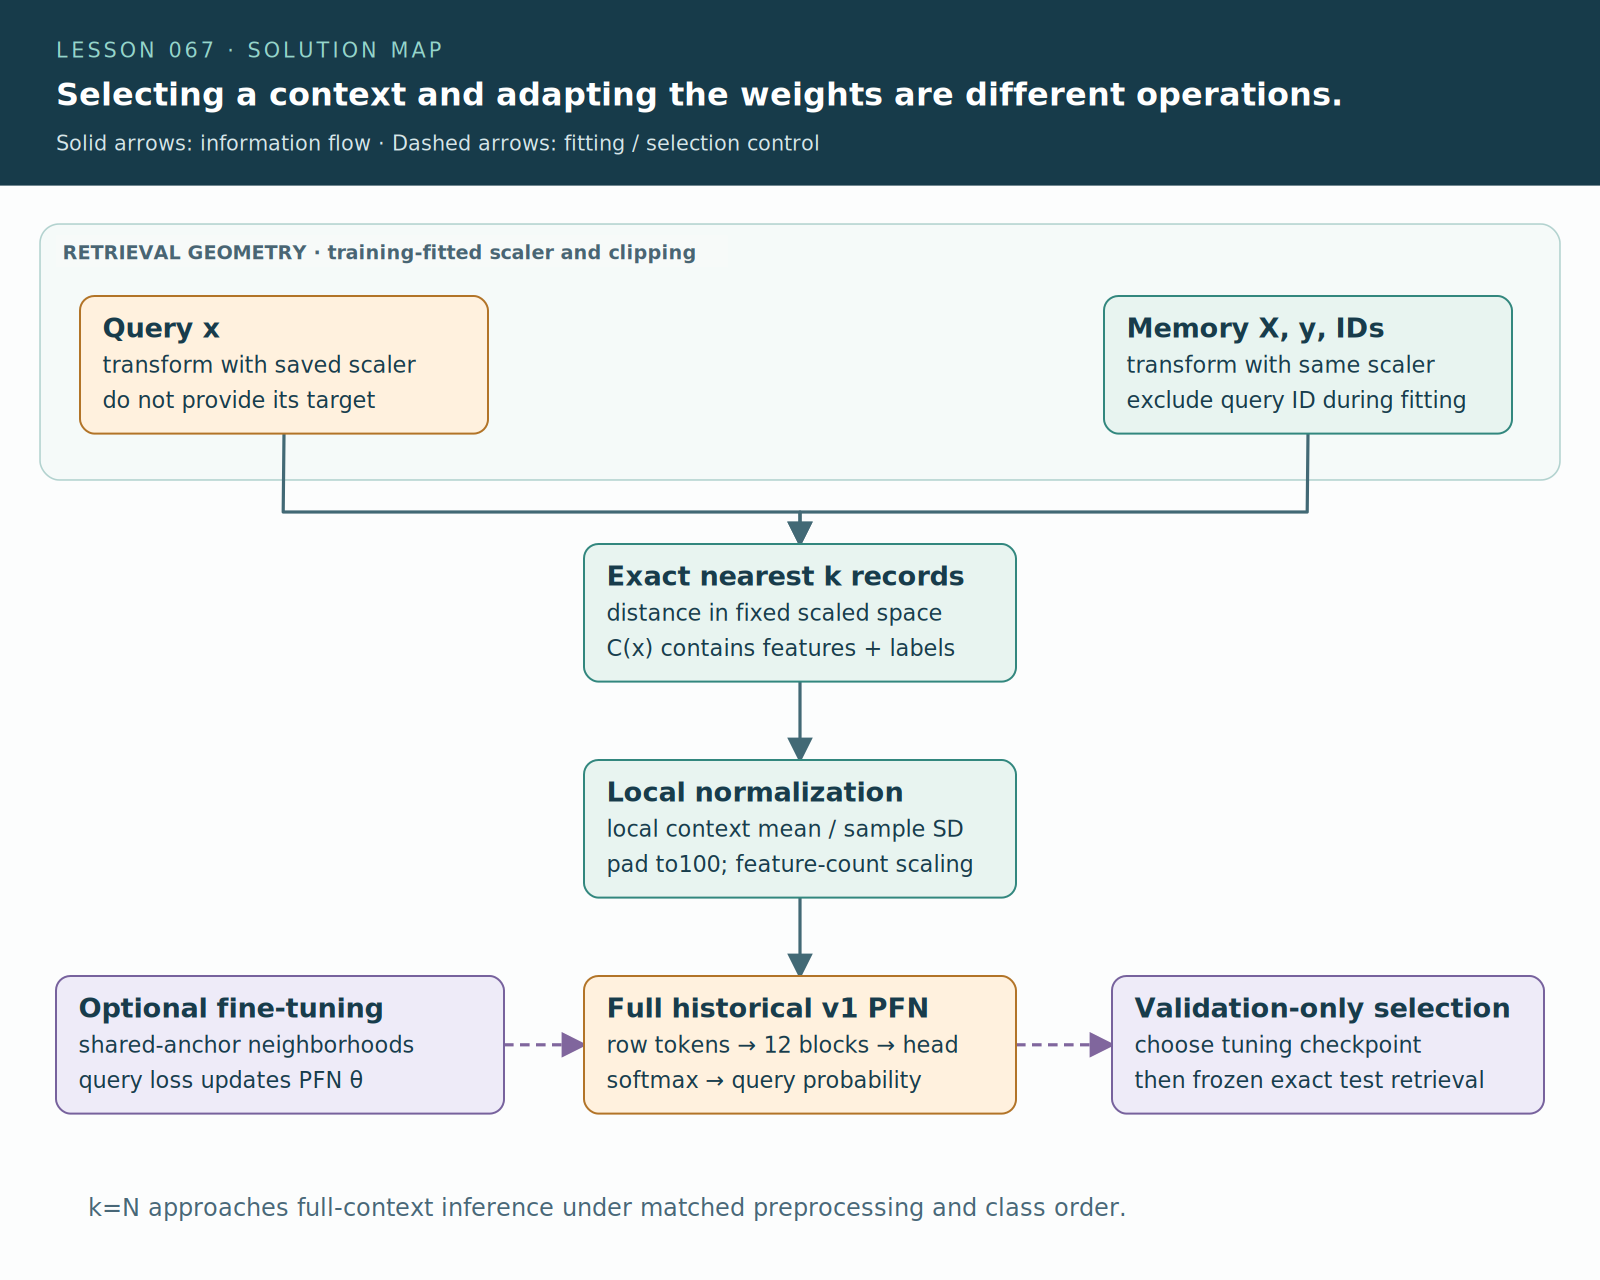</div>

**How the parts work together:** No. Frozen local inference composes retrieval with the pretrained PFN. Fine-tuning adds a separate query-loss gradient path. Approximate training shares anchor neighborhoods; exact inference retrieves for each query.

**Pictured scope:** Historical v1 model: 12 blocks, d=512. Fixed standardized Euclidean retrieval; this is not TabR’s learned key/value correction. Local normalization follows the retrieved context.

[Full-size vector diagram](../assets/solution-maps/0067-local-context.svg). Scroll on narrow screens to keep labels legible.

<details><summary>Text route: components and connections</summary><ol><li><strong>Query x</strong>: transform with saved scaler; do not provide its target. Connects to Exact nearest k records.</li><li><strong>Memory X, y, IDs</strong>: transform with same scaler; exclude query ID during fitting. Connects to Exact nearest k records.</li><li><strong>Exact nearest k records</strong>: distance in fixed scaled space; C(x) contains features + labels. Connects to Local normalization.</li><li><strong>Local normalization</strong>: local context mean / sample SD; pad to100; feature-count scaling. Connects to Full historical v1 PFN.</li><li><strong>Full historical v1 PFN</strong>: row tokens → 12 blocks → head; softmax → query probability. Connects to Validation-only selection (fitting/selection control).</li><li><strong>Optional fine-tuning</strong>: shared-anchor neighborhoods; query loss updates PFN θ. Connects to Full historical v1 PFN (fitting/selection control).</li><li><strong>Validation-only selection</strong>: choose tuning checkpoint; then frozen exact test retrieval.</li></ol></details>

In exact arithmetic, a constant local feature has s=0 and centered value zero. Floating-point reductions need more care. The released source pads first, forms a contiguous T × B × 100 tensor and uses explicit masked sum/count reductions. A real diabetes context with a constant feature exposed cancellation: in a recorded float32 fixture, the official transformed value was about 2.399 while an algebraically equivalent mean/std shortcut gave zero. The [independent precision diagnostic](_normalization_l067_results.json) shows that float64 removes this discrepancy on that fixture. Our implementation preserves the source layout and operation order, including division by F/100. This source match is not an endorsement of amplified rounding, and 2.399 is a fixture-specific value, not a rule for constants. The stabilizer and clamp keep the finite numeric path bounded. In this numeric subset, inputs are finite; missing-value handling is outside the experiment. Query values never fit either set of statistics. Float32 reduction layout can nevertheless affect rounding, so inference microbatch size remains part of the saved runtime contract; mathematical query isolation is not a promise of bitwise equality across every batching layout. Do not substitute the historical v1 classifier's power transformations, constant-column removal or logarithmic outlier compression. LoCalPFN's released `ftknn.py` calls `PFN.forward` with normalization enabled and outlier clipping disabled. Its probability path uses softmax at temperature 1; the `inf_temperature=0.8` configuration field is not used in these local evaluation functions.

## Model architecture: the complete pretrained model inside retrieval

The checkpoint contains 12 transformer blocks, width 512, four attention heads of width 128, a feed-forward width of 1,024, and a 10-logit output head. The visible implementation loads every model tensor from the original checkpoint, including the feature encoder, scalar label encoder, all repeated blocks and decoder. It is the same full architecture introduced in Lesson 062, with a wrapper matching the LoCalPFN local path. No reduced PFN or new randomly initialized miniature supplies the measurements.

For a batch of B independent contexts, input features have shape B × (C+Q) × F and known context labels have shape B × C. After local normalization and padding, the feature encoder maps 100 → 512. A separate affine map sends each scalar context label to 512 coordinates, and this embedding is added to the corresponding context row. Query rows receive their own feature embedding but no label embedding. Integer label encoding here is the historical architecture; it should not be confused with a numeric regression target.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"></div>

Complete historical v1 checkpoint inside LoCalPFN: 12 blocks, width 512, four heads, FFN 1024, context-only keys/values, query-only output. Local fine-tuning updates every neural stage; retrieval IDs remain discrete. [Full-size figure](figures/l067/architecture-v2.png).

**Connecting the ideas.** Per-query neighborhoods describe the desired prediction rule. Training can share an anchor neighborhood across several queries to reduce cost, but that is an approximation with a different batch layout. Compare what is reused before comparing runtimes.

Each block projects the row states into queries, keys and values. All rows provide attention queries, but only context rows supply keys and values. For one head, A = softmax(QKᵀ/√128), followed by AV. The matrix has C+Q receiving rows and C sending columns. A context row can read any context row, including itself. A query reads context only; it cannot read another query or itself through the key/value path. Its own features still travel through the query projection and residual stream. Masking keys does not erase the query.

The block applies LayerNorm(h + attention(h)), then a 512 → 1,024 → 512 GELU feed-forward transformation inside a second residual addition and LayerNorm. These are post-addition normalizations. Repeat this complete block 12 times. The decoder maps each resulting query row through 512 → 1,024 → 10, with GELU between the linear layers. Slice the first K logits for the class universe defined by the outer training labels, then apply softmax.

That last clause prevents an easy bug. If a retrieved context contains only class 0, K is still 2 for a binary task. The pretrained network can produce two logits and need not be replaced with a constant predictor. If a held-out batch happens to contain one target class, its unseen labels must not resize the model's output axis. The official `eval_ft_knn` derives its class count from evaluation targets; our version deliberately fixes the axis from outer training data. The model's forward signature never accepts query labels. The checker changes dummy query labels in the official call to verify they do not influence its logits.

Original synthetic prior fitting produced the starting weights and is not repeated here. Frozen local inference updates no weights. Fine-tuning starts from a fresh copy of those weights for each dataset, split and learning-rate arm; the same complete model remains trainable. A changed weight checksum shows that optimization happened, not that its selected test prediction improved.

## Exact inference and approximate training are different batch layouts

At deployment, each query has its own k-neighbor context. If we predict R held-out rows at once, the conceptual layout is B=R, C=k, Q=1. Sharing a batch dimension does not mean sharing a context. In contrast, a global context uses B=1, C=k and Q=R. It computes the context representation once for all R queries.

This distinction explains the paper's training approximation. With R supervised queries, exact local training would repeat the context computation R times. Instead, choose B anchors from training memory. Around each anchor, retrieve C+Q nearby rows; exclude that anchor by original row identity. Shuffle the retrieved rows and split them into C context rows and Q supervised query rows. One forward pass now trains B×Q queries while representing only B contexts.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Illustrative shared neighborhood around anchor 0. Its query −2 would retrieve a different context at exact inference. Original anchor identity is excluded from its training neighborhood." src="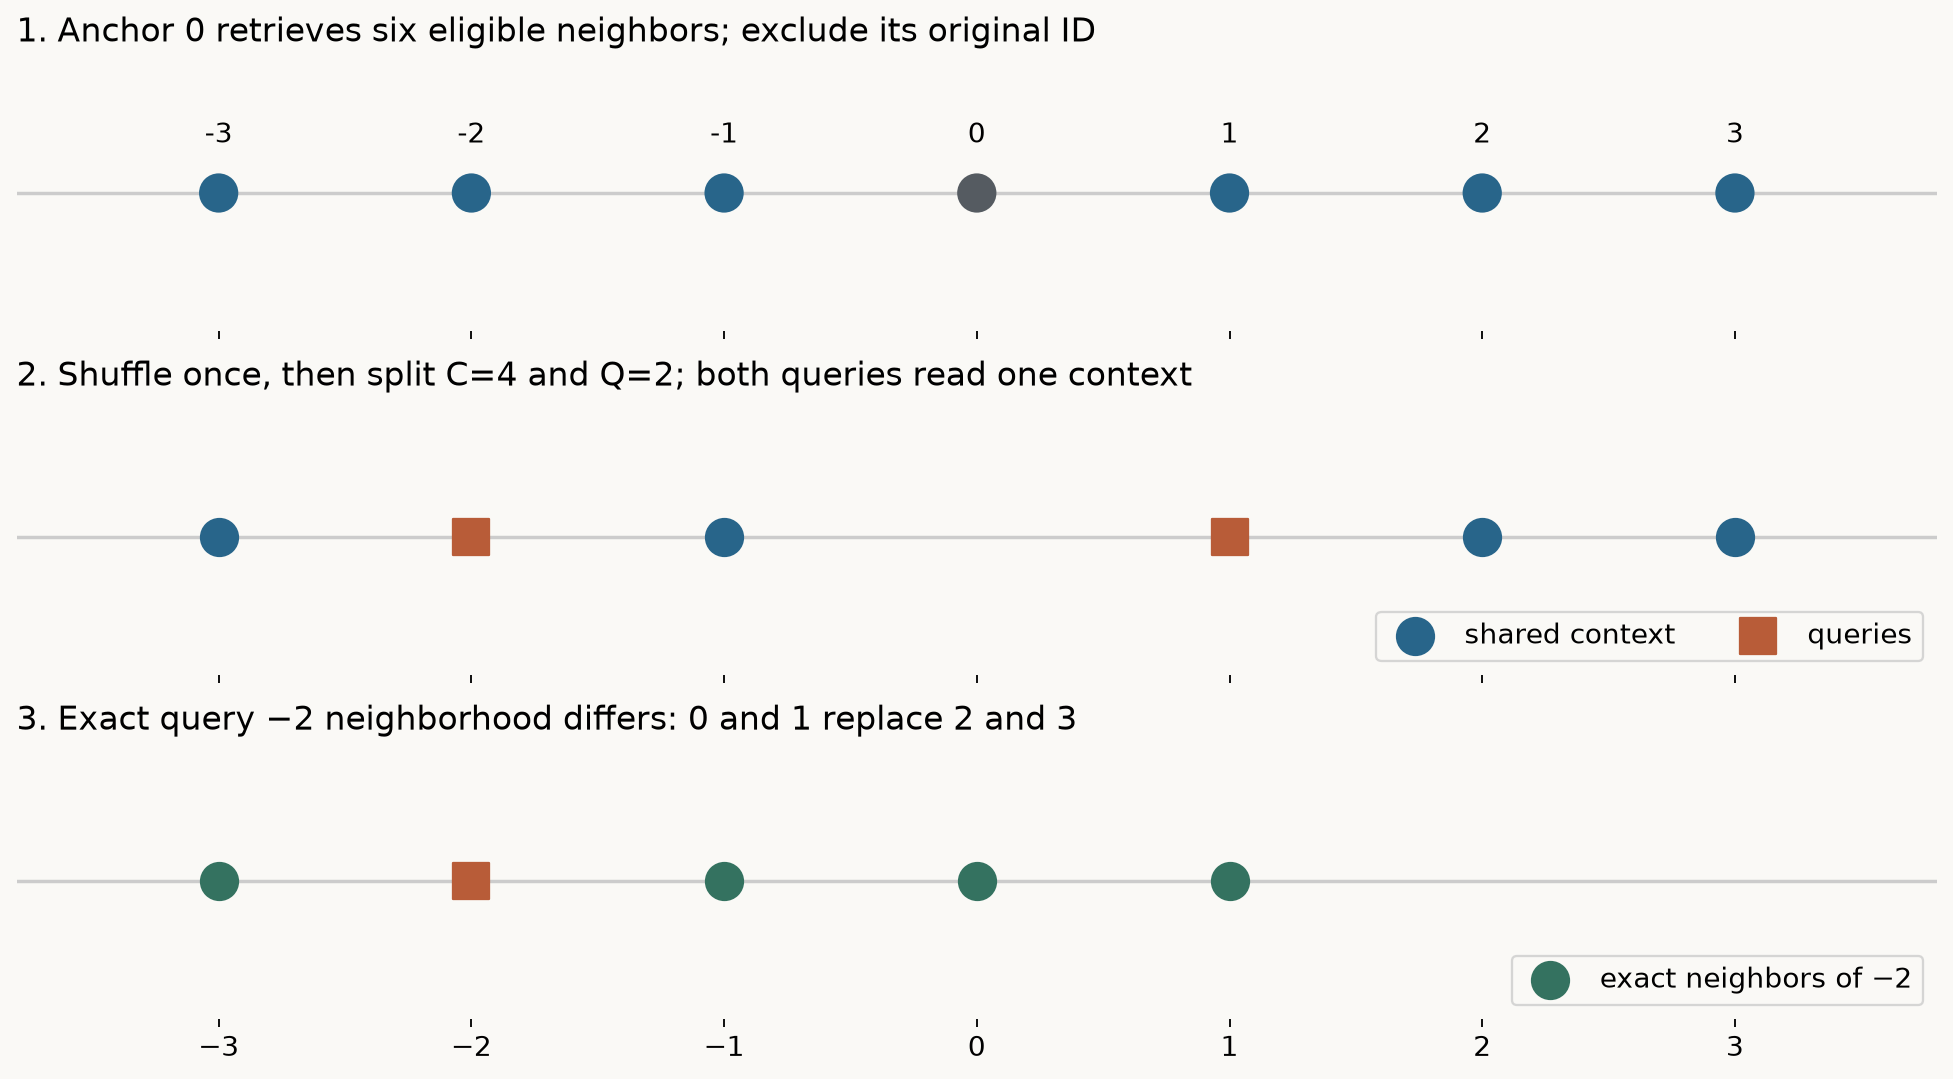" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Illustrative shared neighborhood around anchor 0. Its query −2 would retrieve a different context at exact inference. Original anchor identity is excluded from its training neighborhood. [Full-size figure](figures/l067/episodes-v2.png).

Consider a one-dimensional memory with anchor 0 and nearby eligible points −3, −2, −1, 1, 2 and 3. A possible random split puts [−3,−1,2,3] in context and [−2,1] in queries. These queries share a local vicinity, but the context is not the exact four-neighbor set of either query. The point at 3 is farther from −2 than the withheld query at 1. The approximation is neighborhood sharing, even if the search around the anchor was an exact Euclidean search. Replacing the search engine with approximate FAISS indexing would address a different cost.

Exclusion must use row identity. Two distinct customers can have identical feature values. Removing every distance-zero row would remove both; removing the first sorted neighbor can leave the anchor under ties. Our stable tie policy preserves candidate row order and masks the matching original ID. Context and query IDs are disjoint within each episode. Episodes may overlap each other because every one is drawn from the authorized outer training pool. Such overlap is ordinary minibatch reuse, not test leakage.

There is a paper/source discrepancy worth preserving rather than hiding: final paper footnote 2 explicitly excludes the anchor, while the released `train_ft_knn` retains it in the search result before shuffling. Retaining one anchor does not itself put the same row into both context and query, but it changes the sampling distribution. The active lab follows the paper's exclusion rule and records every anchor and episode. Copied-input source checks compare the same constructed episodes; they do not certify equality of those two samplers.

## How much computation does sharing save?

Ignoring heads and layers, exact local prediction for R queries has R·k(k+1) permitted query-key pairs. B shared training contexts with Q=R/B queries have B·k(k+Q) = Bk²+Rk scores. For R=32, k=100 and B=2, exact contexts require 323,200 scores per head per layer, while sharing requires 23,200: approximately 13.9 times fewer permitted pairs. Multiply both by four heads and 12 layers for this backbone. This is an arithmetic comparison of permitted attention pairs and of our explicit rectangular implementation, not a measured wall-clock speedup. The released PFN calls a square TransformerEncoderLayer with a boolean mask; its backend may also represent masked query-key positions. The count therefore does not claim an identical materialized score tensor or FLOP count for that source path.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Illustrative attention-score count, R=32/k=100/B=2: 323200 exact versus 23200 shared per head per layer. These are permitted-pair counts for rectangular attention, not original square-mask tensor sizes or measured timing." src="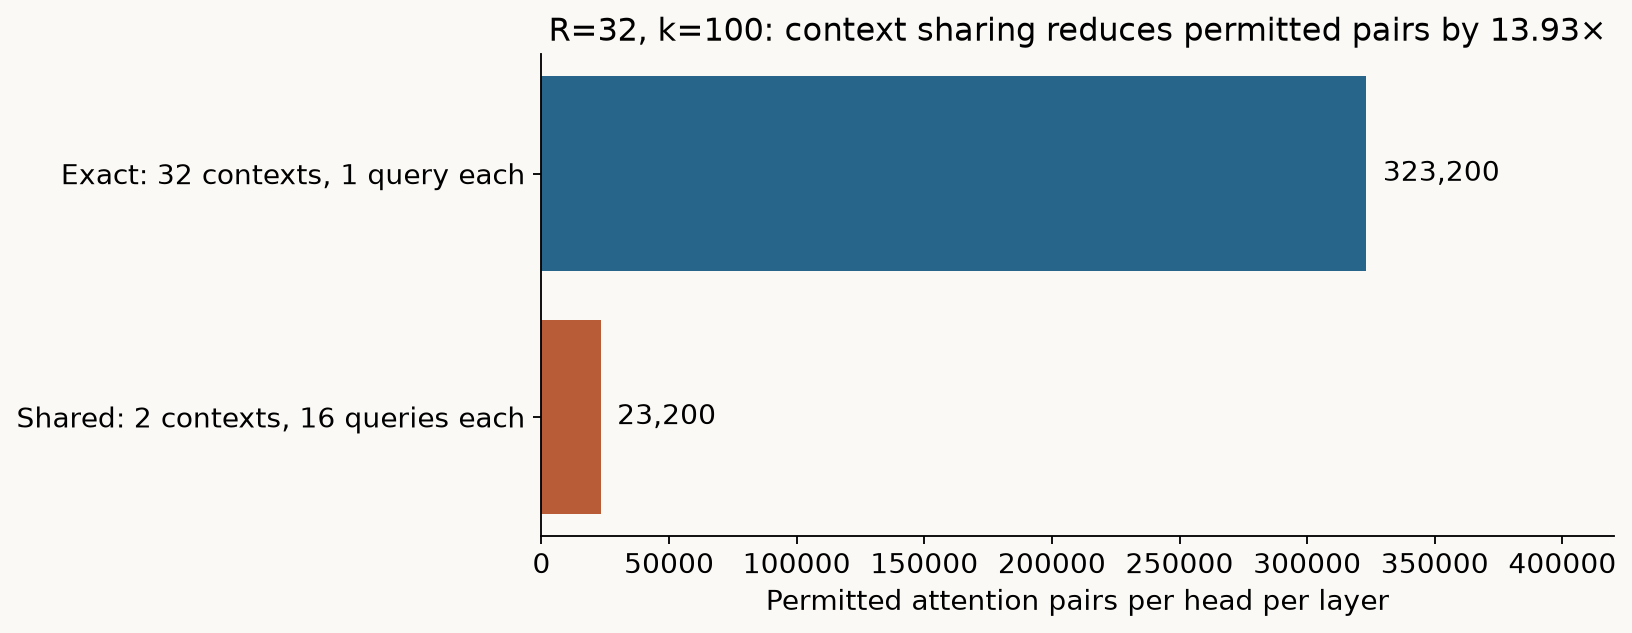" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Illustrative attention-score count, R=32/k=100/B=2: 323200 exact versus 23200 shared per head per layer. These are permitted-pair counts for rectangular attention, not original square-mask tensor sizes or measured timing. [Full-size figure](figures/l067/cost-v2.png).

**Connecting the ideas.** Retrieval can change predictions with fixed weights. Fine-tuning adds a second adaptation route through query loss and gradient updates. Validation selects its checkpoint; test must evaluate the frozen combination of retrieval and adapted weights.

The feed-forward networks and projections also do work on every row. Exact training transforms R(k+1) rows, while shared training transforms Bk+R. Retrieval itself costs roughly R·N·F for a brute-force search over N memory rows; the local reference uses an exact FAISS index, and the lab uses vectorized exact distances with deterministic ties. CPU inference microbatches of four bound memory without changing each query's neighborhood. The actual paper uses inference batches of 512 and different hardware.

The final paper's Section 4.5 separates training cost from inference latency. LoCalPFN and frozen TabPFN-kNN have the same inference architecture; adaptation adds training work. Its reported inference times are slower than trees even where total fit-plus-evaluate time is competitive. This distinction matters for millions of production queries. Our CPU timing cannot reproduce the RTX 6000 Ada runtime table or establish throughput for a production workload.

## Fine-tune the query loss, then select using validation only

For episode b and query j, let pᵦⱼ be the probability assigned to its known training target. The objective is L(θ) = −Σᵦⱼ log pᵦⱼ /(B·Q). The context labels influence the forward pass, while the query labels appear only in this loss. There is no auxiliary loss on the context rows. A cross-entropy helper must slice the global K-class axis and average across both batch and query dimensions; averaging only the final query or flattening the class axis into the batch changes the objective.

For a numerical loss trace, suppose two query targets receive probabilities 0.8 and 0.25. Their negative log probabilities are approximately 0.2231 and 1.3863, so the mean query loss is 0.8047. An overconfident mistake can dominate this mean even when most classifications are right. For logits followed by softmax and cross entropy, the per-query logit gradient is p−one_hot(y), divided by the number of queries when forming the mean. That signal flows through the query head and the context-dependent transformer computation; there is no gradient through the discrete neighbor IDs. “End-to-end” adaptation here means updating the whole PFN on retrieved-context episodes; the default Euclidean retriever remains fixed. Joint retrieval and fine-tuning does not imply a differentiable neighbor selector.

AdamW maintains first and second moving averages of each gradient. After bias correction it takes a learning-rate-scaled step divided by the square root of the second moment plus an epsilon, and separately decays the parameter by a factor 1−learning_rate·weight_decay. All pretrained weights are eligible for updates. The paper specifies learning rate 0.01, weight decay 0.01, no warmup and no scheduler. Section 4.1 says the learning rate was tuned manually across tasks, rather than selected separately for each dataset. The released CLI defaults to 10⁻⁵, a 1,000-fold difference.

We preserve both authorities with two predeclared diagnostic arms. Both see the same initial weights and exact sequence of training episodes. The primary paper-rate arm uses 0.01; the separately named released-CLI arm uses 10⁻⁵. Neither rate is selected by looking at test results. Comparing them locally can expose sensitivity to the changed CPU episode budget; it cannot reconstruct the authors' undocumented global tuning history.

Validation AUC selects a state before test scoring. AUC is the fraction of positive-negative pairs ranked in the correct order, with half credit for ties. Step 0 must be a candidate: when later adaptation harms validation ranking, retaining the frozen state is a valid result. Our strict earliest-maximum rule retains the earlier state on ties. We evaluate step 0 and step 30, then score only the selected state on the test set. This is two-candidate selection, not a reproduction of a long early-stopping trajectory. Parameter change at the final step can be nonzero even when the selected step is zero.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Illustrative validation histories. The ring identifies the selected state. Test labels are absent; a nonzero final update can be rejected in favor of step 0." src="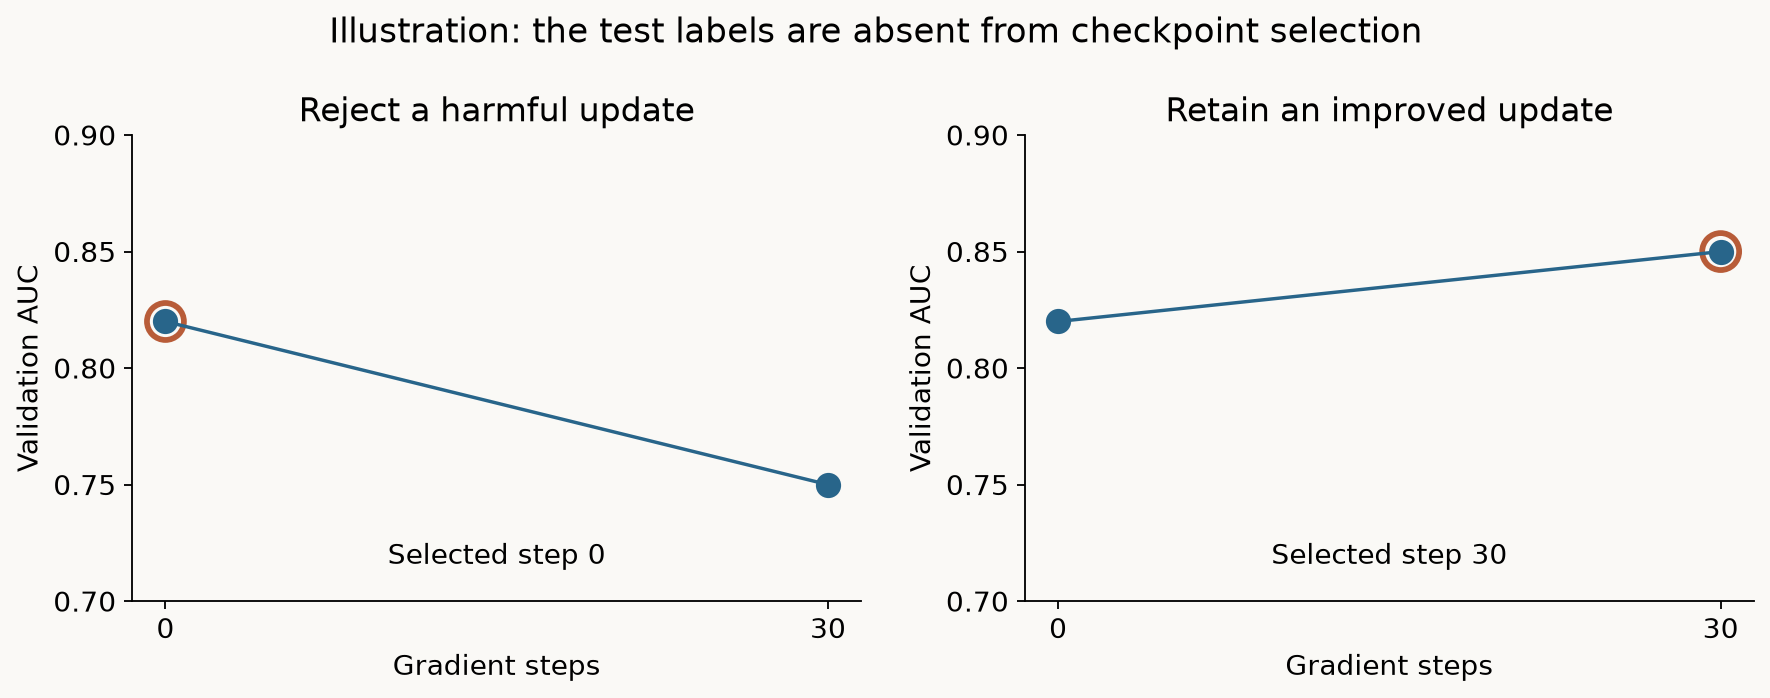" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Illustrative validation histories. The ring identifies the selected state. Test labels are absent; a nonzero final update can be rejected in favor of step 0. [Full-size figure](figures/l067/selection-v2.png).

The notebook's EXIT must bind the actual model methods, helper functions, function-valued defaults, runtime settings and weight tensors used to obtain these scores. A source hash of a file on disk cannot establish that a student ran its functions. A nested generator can call a changed global helper; that dependency must invalidate earlier evidence too. The notebook exercises this failure explicitly and refuses to save a stale result. Author and notebook identities remain separate even when their numerical predictions match.

## What the paper established, and what the fresh lab measures

The final paper reports a study of 95 classification datasets filtered from TabZilla: 47 with fewer than 2,000 rows and 48 medium/large tasks. It uses released 80/10/10 partitions across ten folds, validation AUC, and tree/deep-learning comparison protocols described in Section 4.1 and Appendix A.2. The main TabPFN-based comparison omits extra transformation views and ensembling. Appendix A.2 specifies k = min(10√N_train,1000), batch 2, 1,000 training queries and evaluation every 30 gradient steps. The paper's total-query notation and the released per-context `train_query_length=1000` need to be distinguished when reconstructing a large run. The appendix roster also needs reconciliation: the rendered Table 2 lists 37 names under its “47 Small Datasets” caption, and Table 3 lists 42 under “48 Medium/Large Datasets.” The [roster audit](_paper_audit_l067_v2_results.json) records these counts. The reported 95-task aggregate cannot be reconstructed from those listed 79 names alone; this is a documentation gap, not evidence about which tasks actually ran.

Its main table reports a mean AUC of 0.867 for TabPFN, 0.891 for TabPFN-kNN and 0.908 for LoCalPFN on the 95-task suite. The corresponding IQMs are 0.917, 0.943 and 0.958. IQM averages the middle half of scores and reduces the influence of extremes; it is not the arithmetic mean or a mean rank. Published intervals use the paper's stratified bootstrap procedure. A different dataset roster, split or aggregation is not a matching reproduction even if a decimal happens to agree.

Read ablation tables as carefully as their captions. Final Table 9's caption says adding retrieval after global fine-tuning degrades overall performance. Yet its displayed all-task mean rises from 0.885 to 0.887, while the medium/large mean falls from 0.916 to 0.903. The table supports a subgroup failure and the stronger performance of jointly local fine-tuning; it does not support a universal degradation claim. Table 13 reports similar mean AUC for exact and shared training with 32 queries on medium/large data, supporting that particular approximation comparison rather than exact equality of their neighborhoods.

Our fresh local experiment uses **all rows** of diabetes, blood transfusion and WDBC. These numeric tasks are listed in the paper roster, but our stratified 80/10/10 splits with seeds 7,17,27 are new splits, not the released TabZilla folds. We retain the full pretrained backbone and the dynamic k rule. We use B=2 with 16 queries per context and only 30 gradient updates, selecting between steps 0 and 30. These are substantive training-budget changes. There are no tuned trees, categorical tasks, global-context fine-tuning arm or exact-versus-shared trained ablation in this panel.

Our random-k arm is a label-blind, without-replacement prefix; the released vanilla helper samples with class-proportional quotas and can use replacement. Our global-all arm is an added local diagnostic, not the paper’s capped global baseline. These controls use the same corrected local wrapper to make the local intervention legible, rather than claiming bit-for-bit correspondence with every official baseline helper.

The five prediction arms answer narrower questions: global-all versus random-k checks a context-cap effect; random-k versus local-frozen changes which k rows enter; local-frozen versus either selected local adaptation arm measures the benefit of this bounded adaptation procedure. Without a global-context fine-tuning arm, the panel cannot isolate the interaction between retrieval and gradient adaptation. Context policies also change the inner normalization statistics, so their difference is not an effect of labels alone.

Before revealing the results, predict which learning rate will more often retain step 0. Also predict whether an AUC improvement must reduce log loss. Log loss evaluates probability confidence as well as class ranking; these metrics can disagree without either calculation being wrong.

| Dataset | Arm | AUC mean ± SD | Log loss mean ± SD |
|---|---|---:|---:|
| diabetes | global_all | 0.8331 ± 0.0207 | 0.4746 ± 0.0219 |
| diabetes | random_k | 0.8242 ± 0.0263 | 0.4864 ± 0.0309 |
| diabetes | local_frozen | 0.8326 ± 0.0298 | 0.4813 ± 0.0357 |
| diabetes | local_ft_paper_lr | 0.8326 ± 0.0298 | 0.4813 ± 0.0357 |
| diabetes | local_ft_release_lr | 0.8326 ± 0.0298 | 0.4813 ± 0.0357 |
| blood_transfusion | global_all | 0.7968 ± 0.0387 | 0.4516 ± 0.0292 |
| blood_transfusion | random_k | 0.7838 ± 0.0572 | 0.4755 ± 0.0186 |
| blood_transfusion | local_frozen | 0.7935 ± 0.0387 | 0.4579 ± 0.0296 |
| blood_transfusion | local_ft_paper_lr | 0.7935 ± 0.0387 | 0.4579 ± 0.0296 |
| blood_transfusion | local_ft_release_lr | 0.7896 ± 0.0322 | 0.4599 ± 0.0265 |
| wdbc | global_all | 0.9978 ± 0.0038 | 0.0512 ± 0.0318 |
| wdbc | random_k | 0.9956 ± 0.0065 | 0.0624 ± 0.0395 |
| wdbc | local_frozen | 0.9974 ± 0.0046 | 0.0484 ± 0.0357 |
| wdbc | local_ft_paper_lr | 0.9974 ± 0.0046 | 0.0484 ± 0.0357 |
| wdbc | local_ft_release_lr | 0.9974 ± 0.0046 | 0.0484 ± 0.0357 |

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Fresh full-model author panel: all rows of three numeric datasets, three split seeds, five arms, dynamic paper k, 30 steps, 16 queries/context. Error bars are sample SD, not dataset-population uncertainty." src="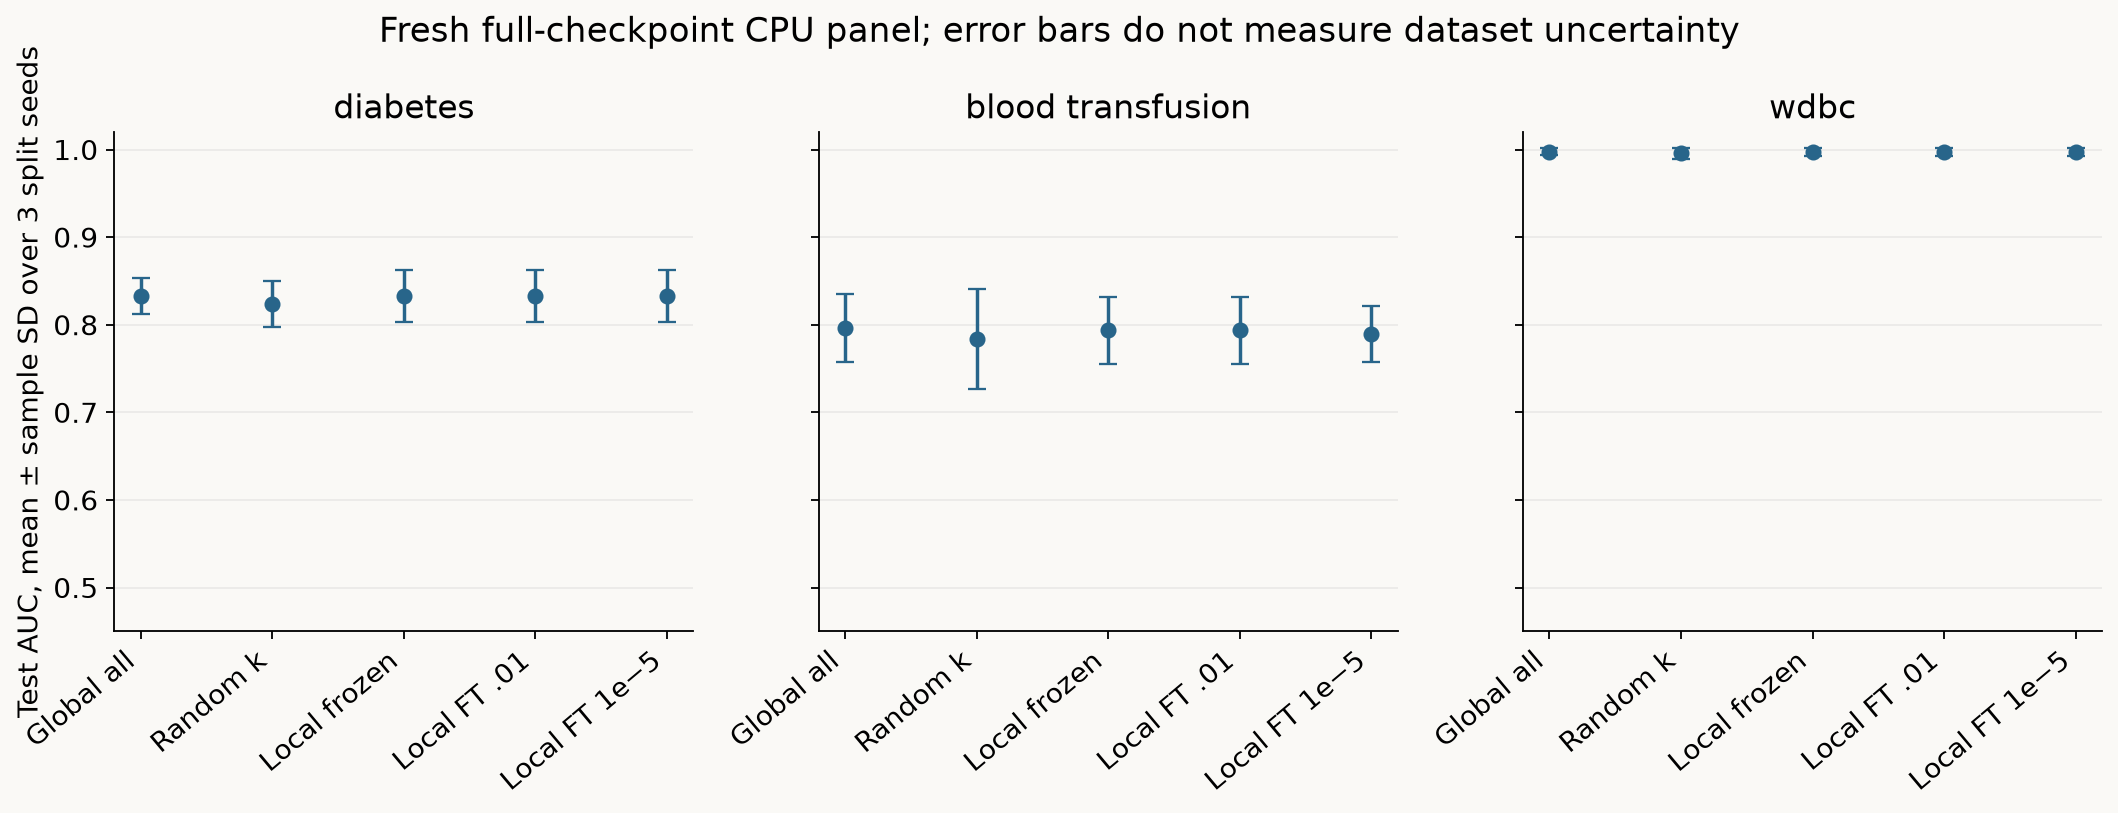" style="width:100%;min-width:1100px;max-width:none;height:auto"></div>

Fresh full-model author panel: all rows of three numeric datasets, three split seeds, five arms, dynamic paper k, 30 steps, 16 queries/context. Error bars are sample SD, not dataset-population uncertainty. [Full-size figure](figures/l067/results-v2.png).

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Five-arm ranks formed after averaging split seeds within each of three datasets. The approximate global-all/random-k distinction is confined to this tiny panel; ties and only three dataset blocks limit generalization." src="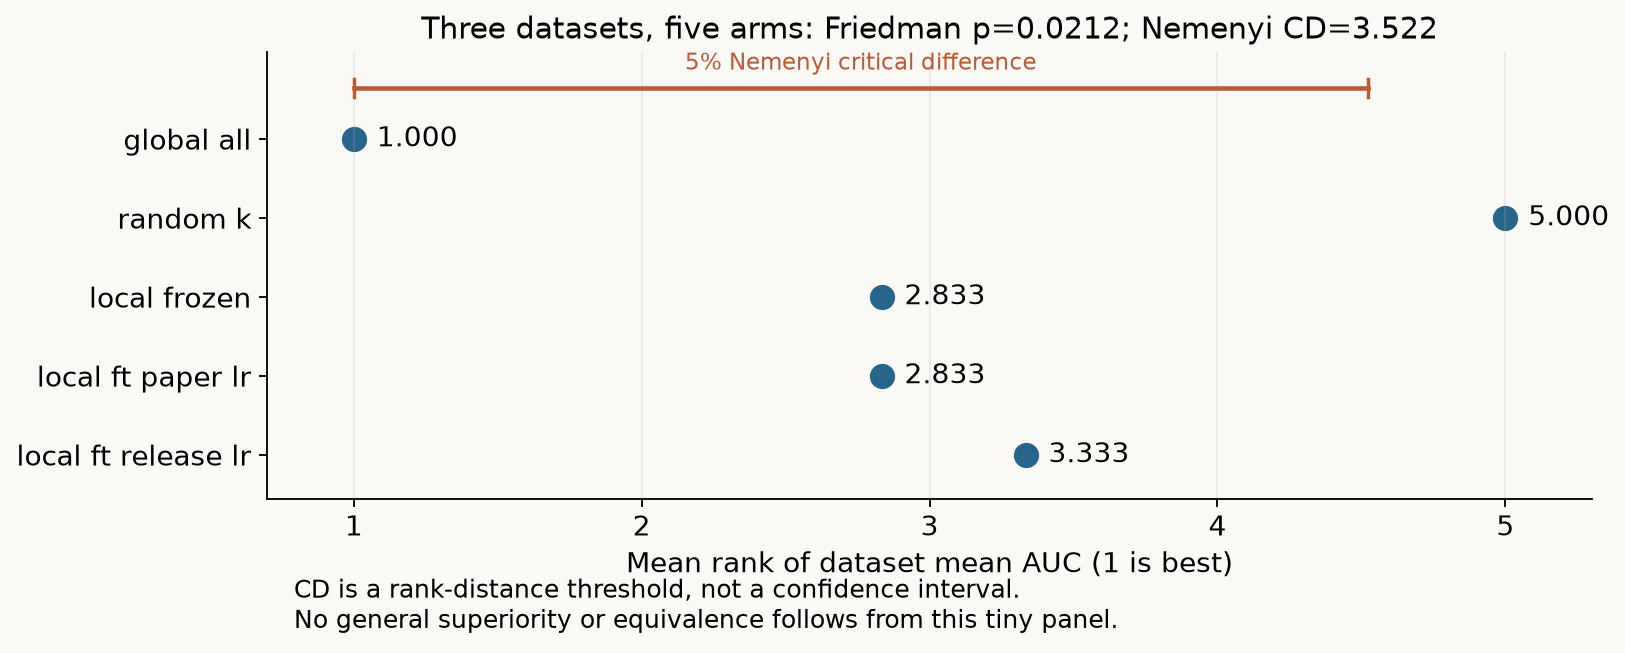" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Five-arm ranks formed after averaging split seeds within each of three datasets. The approximate global-all/random-k distinction is confined to this tiny panel; ties and only three dataset blocks limit generalization. [Full-size figure](figures/l067/ranks-v2.png).

The paper-rate arm retained step 0 in 9/9 runs; the released-CLI-rate arm retained it in 8/9. Every adaptation run records nonzero final parameter change, so retained frozen predictions do not imply that training was skipped. On diabetes, local frozen mean AUC was 0.8326 and local FT at 10⁻⁵ was 0.8326; corresponding mean log losses were 0.4813 and 0.4813. The paired released-rate minus frozen AUC gap is +0.0000, with descriptive split-seed t95 interval [+0.0000, +0.0000]. On blood transfusion, local frozen mean AUC was 0.7935 and local FT at 10⁻⁵ was 0.7896; corresponding mean log losses were 0.4579 and 0.4599. The paired released-rate minus frozen AUC gap is -0.0039, with descriptive split-seed t95 interval [-0.0207, +0.0129]. On wdbc, local frozen mean AUC was 0.9974 and local FT at 10⁻⁵ was 0.9974; corresponding mean log losses were 0.0484 and 0.0484. The paired released-rate minus frozen AUC gap is +0.0000, with descriptive split-seed t95 interval [+0.0000, +0.0000]. Dataset-balanced mean AUC ranks (lower is better) in arm order global-all/random-k/local-frozen/paper-rate/released-rate are 1.000/5.000/2.833/2.833/3.333. Friedman statistic 11.529, p=0.0212; Nemenyi 5% critical difference 3.522. The global-all versus random-k mean-rank gap is 4.000, exceeding this approximate CD; the other pairwise gaps do not. This is a nominal descriptive distinction within this panel, not a general-superiority result. The asymptotic tests have only three dataset blocks and several tied arms; overlapping seed holdouts do not increase that dataset count. A zero-width gap interval when all selected states are step 0 reflects identical deployed predictions, not precise knowledge of adaptation at other budgets.

The discarded paper-rate final state on diabetes seed 7 nearly collapses: its saved validation positive-class probabilities span only 0.0202590246 to 0.0202590451, a range of about 2×10⁻⁸, yet their machine-scale ordering yields AUC 0.52556. AUC depends on ranks, so tiny floating-point perturbations or new ties can noticeably change this statistic even when probabilities agree closely. Inspect probability spread alongside AUC when diagnosing an aggressive update. This state was rejected by validation; its rank sensitivity is not a test-score improvement.

Within each dataset the table reports sample standard deviation across the three split seeds. Those repeated holdouts overlap; the three scores are not independent datasets. The separate paired gap intervals describe this small seed panel under a conventional t approximation and do not capture population-of-datasets uncertainty. Across datasets, first average seeds, rank the five arms within each dataset, then average the three dataset ranks. The accompanying Friedman/Nemenyi calculation is descriptive and severely underpowered with only three datasets and several step-zero ties. Do not treat lack of significance as evidence of equivalence.

The archived older six-step/24-test-row run remains historical evidence under its original operator. It does not inherit the new wrapper, full test sets or evidence checks. The fresh result is **INCOMPARABLE as a paper-result reproduction**. Full source forward/gradient/update agreement, this bounded pretrained adaptation experiment, the original synthetic pretraining and the 95-task benchmark are four separate evidence statements.

## Transfer the mechanism to a relational question

Suppose a model predicts whether a customer will renew at the end of March. A Euclidean neighbor might be another customer with similar current features. A relational context might instead include that customer's earlier purchases, support cases or connected organizations. Those rows are useful only if their feature values and supervision were available before the prediction cutoff. Being close in an embedding does not make a future label eligible.

LoCalPFN teaches how to change the context and update the prediction rule, but its flat IID table experiment does not establish that a graph neighborhood is better. A defensible follow-up freezes the temporal split, feature availability, candidate memory, parameter budget and selection rule before replacing Euclidean retrieval. Measure whether the relational context improves the task and whether that improvement survives a matched context-size and latency comparison.

For comparison with earlier lessons: TabR learns a task-specific representation and retrieves labeled neighbors within its own supervised architecture. LoCalPFN starts from a pretrained dataset-to-prediction rule and uses retrieved rows as its context. TabICL's column/row compression addresses a different full-model computation; it does not automatically confer LoCalPFN's retrieval behavior. Transferring this paper's method to either backbone is an experiment, not a conclusion established by the 2024 paper.

## Lab, EXIT and the next reproduction step

The notebook is a standalone lab with five live implementation tasks: deterministic eligible neighbors; shared context/query splitting; local normalization and pretrained input scaling; query-only cross entropy; and earliest-best validation selection. The complete model, training loop and evidence identity logic are visible beside their explanations. Each TODO is used by the fresh full-model experiment. The teacher's numerical source check compares logits, all 152 parameter-gradient tensors and one full AdamW update against the official PFN implementation on the same episodes.

Submit `data/cache/l067-student/exit-v2.json` with your actual predictions, original neighbor/episode IDs, validation histories, weight identities and interpretation. Explain one selected-zero case, one metric disagreement, the difference between exact inference and approximate training, and the paper/source discrepancy in learning rate. A length check only verifies that an explanation was attempted; it does not award mastery. Bring your explanation or a failing CHECK back to the teacher for review.

After EXIT, the supported broader operator repeats the three-dataset/three-seed local panel with your visible implementation. The [reproduction contract](l067-reproduction.md) gives exact commands, artifact paths and the remaining 95-task requirements. A `paper` preset fails explicitly because that benchmark is not implemented here. Local checkpoint weights and teacher solutions are retained in the ignored cache, with recorded hashes and a public fresh-run procedure. Live Colab, cloud execution and original paper-result parity remain separate unperformed checks until their own evidence exists.

## PROVIDED · Runtime and dependencies

Read the definitions before running them. All model and local-algorithm definitions execute in this notebook’s namespace. The official PFN is used only for numerical comparison. Fresh CPU measurements can take several minutes; original checkpoint weights are reused, not retrained from the synthetic prior.

In [ ]:
# PROVIDED — numerical libraries and fresh output directory
import os,sys,copy,hashlib,inspect,importlib.metadata,json,math,time,types
from pathlib import Path
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss,roc_auc_score,accuracy_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import pandas as pd
for directory in [Path.cwd(),Path.cwd()/'labs',Path.cwd().parent]:
    if (directory/'relkit').is_dir():ROOT=directory.resolve();sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run bootstrap or start Jupyter in labs')
torch.set_num_threads(1)
output=Path(os.environ.get('L067_OUTPUT',str(ROOT/'data/cache/l067-student')));output.mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED — checkpoint and explicit experiment contracts
CHECKPOINT_SHA='3c9aadaeddbf51462af8c0ee4b3ca3c697890f77e92318abbb0821b75261c392'
CHECKPOINT_URL='https://raw.githubusercontent.com/PriorLabs/TabPFN/v1.0.0/tabpfn/models_diff/prior_diff_real_checkpoint_n_0_epoch_42.cpkt'
MODEL_CONFIG={'features': 100, 'width': 512, 'heads': 4, 'hidden': 1024, 'layers': 12, 'classes': 10}
PROTOCOL={'version': 'l067-v2', 'outer_split': 'stratified80/10/10', 'metric': 'validation AUC', 'temperature': 1.0, 'retrieval': 'train StandardScaler ddof0 then clip10; exact squared Euclidean stable row order', 'model_input': 'local context sample std ddof1 epsilon1e-6 clamp100 then100/F pad100', 'anchor': 'excluded by original identity per final paper footnote2', 'optimizer': 'AdamW', 'weight_decay': 0.01, 'lr_authority': {'.01': 'final paper AppendixA.2.2', '1e-5': 'released config.py default'}, 'query_labels': 'loss only; global training class axis remains fixed', 'paper_reproduction': 'INCOMPARABLE'}
PRESETS67={'smoke': {'datasets': ['diabetes'], 'seeds': [7], 'steps': 2, 'eval_every': 2, 'max_context': 32, 'queries': 4, 'batch': 2, 'lrs': [0.01, 1e-05], 'inference_batch': 4}, 'lab': {'datasets': ['diabetes'], 'seeds': [7], 'steps': 30, 'eval_every': 30, 'max_context': 1000, 'queries': 16, 'batch': 2, 'lrs': [0.01, 1e-05], 'inference_batch': 4}, 'closer': {'datasets': ['diabetes', 'blood_transfusion', 'wdbc'], 'seeds': [7, 17, 27], 'steps': 30, 'eval_every': 30, 'max_context': 1000, 'queries': 16, 'batch': 2, 'lrs': [0.01, 1e-05], 'inference_batch': 4}}

## TODO 1 · Eligible exact neighbors

**Goal:** Return Q×k memory indices with deterministic ties and identity exclusion.

**Why:** A duplicate feature vector is not the same row; this function supplies both training episodes and inference contexts.

**Hint boundary:** Compute squared distances, mask matching original IDs, then select in stable order.

In [ ]:
# TODO — neighbor_ids
def neighbor_ids(memory,queries,k,memory_ids=None,exclude_ids=None):
    raise NotImplementedError("Implement this live local adaptation operation")

In [ ]:
# CHECK — neighbor_ids
x=np.array([[0.,0.],[0.,0.],[2.,0.],[3.,0.]])
assert neighbor_ids(x,x[:1],2,[10,11,12,13],[10]).tolist()==[[1,2]], 'Exclude identity, retain duplicate row11'
assert neighbor_ids(x,x[:1],2).tolist()==[[0,1]], 'Stable tie order'
print("CHECK passed: neighbor_ids")

## TODO 2 · A context shared by several queries

**Goal:** Shuffle each retrieved neighborhood with the same drawn column permutation, then return context/query indices.

**Why:** This is the paper’s load-bearing training approximation, not an approximate search engine.

**Hint boundary:** Draw one permutation of neighborhood columns; every row belongs to exactly one side within its episode.

In [ ]:
# TODO — episode_indices
def episode_indices(neighbors,context_size,rng):
    raise NotImplementedError("Implement this live local adaptation operation")

In [ ]:
# CHECK — episode_indices
neighbors=np.array([[1,2,3,4,5],[5,4,3,2,1]])
c,q=episode_indices(neighbors,3,np.random.default_rng(4))
assert c.shape==(2,3) and q.shape==(2,2)
assert all(not set(a)&set(b) for a,b in zip(c,q))
assert all(set(a)|set(b)==set(n) for a,b,n in zip(c,q,neighbors))
assert np.array_equal(np.argsort(np.concatenate([c,q],1)[0]),np.argsort(-np.concatenate([c,q],1)[1]))
print("CHECK passed: episode_indices")

## TODO 3 · Match the pretrained local input

**Goal:** Return padded B×(C+Q)×100 model inputs normalized from context rows only.

**Why:** Wrong variance convention or reversed scaling order changes the full checkpoint’s input.

**Hint boundary:** Pad, transpose to contiguous T×B×100, then use explicit masked sum/count and centered-square reductions. Normalize with epsilon 1e-6, clamp ±100, divide by F/100, transpose back; preserve the source float32 operation order.

In [ ]:
# TODO — local_normalize
def local_normalize(x,context_size,max_features=100):
    raise NotImplementedError("Implement this live local adaptation operation")

In [ ]:
# CHECK — local_normalize
x=torch.tensor([[[0.,1.],[2.,1.],[4.,1.],[3.,5.]]])
z=local_normalize(x,3,max_features=4)
torch.testing.assert_close(z[0,:,0],torch.tensor([-2.,0.,2.,1.]),atol=2e-6,rtol=0)
assert z.shape==(1,4,4) and z[0,-1,1]==200 and not z[...,2:].any()
y=x.clone();y[0,-1,0]=999;torch.testing.assert_close(local_normalize(y,3,4)[:,:3],z[:,:3])
print("CHECK passed: local_normalize")

## TODO 4 · Supervise only episode queries

**Goal:** Compute one mean cross entropy over all B×Q query targets on the fixed training class axis.

**Why:** Context labels are inputs; query labels are targets. A context missing a class must not shrink the output.

**Hint boundary:** Preserve K as the last dimension when flattening query positions.

In [ ]:
# TODO — query_loss
def query_loss(logits,targets,classes):
    raise NotImplementedError("Implement this live local adaptation operation")

In [ ]:
# CHECK — query_loss
z=torch.zeros(2,3,10,requires_grad=True);y=torch.tensor([[0,1,0],[1,1,0]])
loss=query_loss(z,y,2);torch.testing.assert_close(loss,torch.tensor(math.log(2)))
loss.backward();assert not z.grad[...,2:].any()
assert torch.allclose(z.grad[0,0,:2],torch.tensor([-1/12,1/12]))
print("CHECK passed: query_loss")

## TODO 5 · Keep the earliest best validation state

**Goal:** Return the index of the first maximum finite validation AUC.

**Why:** Step 0 protects the pretrained solution from a harmful update and ties must have a declared rule.

**Hint boundary:** Validate finite nonempty input and choose using validation only.

In [ ]:
# TODO — validation_choice
def validation_choice(scores):
    raise NotImplementedError("Implement this live local adaptation operation")

In [ ]:
# CHECK — validation_choice
assert validation_choice([.7,.7,.6])==0
assert validation_choice([.7,.8,.8])==1
try:validation_choice([float('nan')])
except ValueError:pass
else:raise AssertionError('Reject nonfinite validation scores')
print("CHECK passed: validation_choice")

## PROVIDED · The full original backbone

These are the unchanged complete L062 model definitions. Follow context-only K/V into all 12 postnorm blocks and the full 10-logit head. Both feature and label encoders remain trainable.

In [ ]:
# PROVIDED — attention_mix
def attention_mix(q,k,v):
    """B×H×receivers×headwidth; only context keys/values are supplied."""
    return torch.softmax(q@k.transpose(-2,-1)/math.sqrt(q.shape[-1]),dim=-1)@v

In [ ]:
# PROVIDED — postnorm_update
def postnorm_update(h,attention_output,block):
    """Attention residual/norm then GELU FFN residual/norm, dropout=0."""
    h=block.norm1(h+attention_output)
    return block.norm2(h+block.ff2(nn.functional.gelu(block.ff1(h))))

In [ ]:
# PROVIDED — V1Block
class V1Block(nn.Module):
    def __init__(self,width,heads,hidden):
        super().__init__();self.width=width;self.heads=heads
        if width%heads:raise ValueError('heads must divide width')
        self.qkv=nn.Linear(width,3*width);self.out=nn.Linear(width,width)
        self.ff1=nn.Linear(width,hidden);self.ff2=nn.Linear(hidden,width)
        self.norm1=nn.LayerNorm(width);self.norm2=nn.LayerNorm(width)
        nn.init.xavier_uniform_(self.qkv.weight);nn.init.zeros_(self.qkv.bias)
        for layer in [self.out,self.ff2]:nn.init.zeros_(layer.weight);nn.init.zeros_(layer.bias)
    def forward(self,h,n):
        b,t,d=h.shape
        q,k,v=self.qkv(h).reshape(b,t,3,self.heads,d//self.heads).permute(2,0,3,1,4)
        # Rectangular attention computes n*n + query*n scores; no query self edge.
        mixed=attention_mix(q,k[:,:,:n],v[:,:,:n])
        mixed=mixed.transpose(1,2).reshape(b,t,d)
        return postnorm_update(h,self.out(mixed),self)

In [ ]:
# PROVIDED — TabPFNv1
class TabPFNv1(nn.Module):
    def __init__(self,features=100,width=512,heads=4,hidden=1024,layers=12,classes=10):
        super().__init__();self.config=dict(features=features,width=width,heads=heads,hidden=hidden,layers=layers,classes=classes)
        self.x_encoder=nn.Linear(features,width);self.y_encoder=nn.Linear(1,width)
        self.blocks=nn.ModuleList([V1Block(width,heads,hidden) for _ in range(layers)])
        self.head=nn.Sequential(nn.Linear(width,hidden),nn.GELU(),nn.Linear(hidden,classes))
    def forward(self,x,y):
        # x:B×(C+Q)×100, y:B×C. Query labels cannot enter this signature.
        n=y.shape[1]
        if x.ndim!=3 or y.ndim!=2 or x.shape[0]!=y.shape[0] or not 1<=n<x.shape[1]:raise ValueError('Bad context/query shape')
        h=self.x_encoder(torch.nan_to_num(x))
        h=torch.cat([h[:,:n]+self.y_encoder(y.to(x.dtype).unsqueeze(-1)),h[:,n:]],dim=1)
        for block in self.blocks:h=block(h,n)
        return self.head(h[:,n:])

## PROVIDED · Checkpoint and real data

The immutable 103 MB checkpoint is SHA-checked and every model weight strictly loaded. Only the criterion buffer is excluded. Loaders preserve original row IDs in the later split.

In [ ]:
# PROVIDED — load_pretrained
def load_pretrained(path,model=None):
    """Strict complete weight mapping; criterion buffer is the only non-model entry."""
    path=Path(path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Unexpected checkpoint bytes')
    state,_,config=torch.load(path,map_location='cpu',weights_only=False)
    state={k.removeprefix('module.'):v for k,v in state.items()}
    model=TabPFNv1(**MODEL_CONFIG) if model is None else model
    mapped={}
    for key,value in state.items():
        if key=='criterion.weight':continue
        new=key.replace('transformer_encoder.layers.','blocks.').replace('self_attn.in_proj_weight','qkv.weight').replace('self_attn.in_proj_bias','qkv.bias').replace('self_attn.out_proj.','out.').replace('linear1.','ff1.').replace('linear2.','ff2.')
        if new.startswith('encoder.'):new='x_encoder.'+new[len('encoder.'):]
        if new.startswith('decoder.'):new='head.'+new[len('decoder.'):]
        mapped[new]=value
    model.load_state_dict(mapped,strict=True);model.eval()
    return model,config

In [ ]:
# PROVIDED — ensure_checkpoint
def ensure_checkpoint(root):
    import urllib.request
    path=Path(root)/'data/cache/foundation/v1/models_diff/prior_diff_real_checkpoint_n_0_epoch_42.cpkt'
    if not path.exists():
        path.parent.mkdir(parents=True,exist_ok=True);urllib.request.urlretrieve(CHECKPOINT_URL,path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Checkpoint hash mismatch')
    return path

In [ ]:
# PROVIDED — load_dataset
def load_dataset(name):
    """All rows, numeric paper datasets. wdbc is sklearn's same UCI source (569×30)."""
    if name=='wdbc':
        from sklearn.datasets import load_breast_cancer
        data=load_breast_cancer();x=data.data;y=data.target
    else:
        from relkit.data import load_tier_a
        x,y=load_tier_a(name);x=np.asarray(x,dtype=np.float32);y=np.asarray(y)
    _,y=np.unique(y,return_inverse=True)
    return np.asarray(x,dtype=np.float32),y

## PROVIDED · From retrieval IDs to logits

Your local normalization feeds every arm. Exact inference batches distinct contexts with one query each; shared inference processes all queries against one context. Neither function accepts query targets.

In [ ]:
# PROVIDED — episode_logits
def episode_logits(model,x,y,context,query):
    ids=np.concatenate([context,query],axis=1)
    xx=torch.as_tensor(x[ids],dtype=torch.float32);yy=torch.as_tensor(y[context],dtype=torch.float32)
    return model(local_normalize(xx,context.shape[1]),yy)

In [ ]:
# PROVIDED — predict_contexts
def predict_contexts(model,x,y,q,contexts,classes,batch_size=4):
    """Exact per-query contexts, vectorized B datasets, Q=1; never accept query labels."""
    if len(contexts)!=len(q):raise ValueError('One context per query')
    outputs=[];model.eval()
    with torch.no_grad():
        for start in range(0,len(q),batch_size):
            c=contexts[start:start+batch_size];xx=np.concatenate([x[c],q[start:start+batch_size,None,:]],axis=1)
            logits=model(local_normalize(torch.as_tensor(xx,dtype=torch.float32),c.shape[1]),torch.as_tensor(y[c],dtype=torch.float32))[:,0,:classes]
            outputs.append(logits.softmax(-1).cpu().numpy())
    return np.concatenate(outputs)

In [ ]:
# PROVIDED — predict_shared
def predict_shared(model,x,y,q,context,classes):
    """One shared context, all held-out queries; exact same numeric wrapper."""
    model.eval()
    with torch.no_grad():
        xx=torch.as_tensor(np.concatenate([x[context],q])[None],dtype=torch.float32)
        yy=torch.as_tensor(y[context][None],dtype=torch.float32)
        return model(local_normalize(xx,len(context)),yy)[0,:,:classes].softmax(-1).cpu().numpy()

In [ ]:
# PROVIDED — fit_geometry
def fit_geometry(train,other):
    """Official numeric dataset.py transform: train moments, population std, clip10."""
    scaler=StandardScaler().fit(train)
    return [np.clip(scaler.transform(z),-10,10).astype(np.float32) for z in [train,*other]],dict(mean=scaler.mean_.tolist(),scale=scaler.scale_.tolist())

## PROVIDED · Runtime and code identity

Code identity follows nested bytecode and function-valued defaults; weight and actual runtime identities are separate. Module-reference and notebook identities are not interchangeable.

In [ ]:
# PROVIDED — model_digest
def model_digest(model):
    h=hashlib.sha256()
    for name,tensor in model.state_dict().items():
        h.update(name.encode());h.update(str((tuple(tensor.shape),tensor.dtype)).encode());h.update(tensor.detach().cpu().numpy().tobytes())
    return h.hexdigest()

In [ ]:
# PROVIDED — stable_value
def stable_value(v):
    if v is None or isinstance(v,(str,int,float,bool)):return v
    if v is Ellipsis:return 'Ellipsis'
    if isinstance(v,np.generic):return v.item()
    if isinstance(v,(list,tuple)):return [stable_value(i) for i in v]
    if isinstance(v,dict):return {str(k):stable_value(i) for k,i in v.items()}
    if isinstance(v,(set,frozenset)):return sorted([stable_value(i) for i in v],key=repr)
    if isinstance(v,bytes):return v.hex()
    if isinstance(v,Path):return str(v)
    if isinstance(v,types.CodeType):return {k:stable_value(getattr(v,k)) for k in ['co_code','co_consts','co_names','co_varnames','co_freevars','co_cellvars','co_argcount','co_posonlyargcount','co_kwonlyargcount','co_flags']}
    if inspect.isfunction(v):return dict(code=stable_value(v.__code__),defaults=stable_value(v.__defaults__),kwdefaults=stable_value(v.__kwdefaults__),closure=stable_value([c.cell_contents for c in v.__closure__ or []]))
    if inspect.isclass(v):return v.__module__+'.'+v.__qualname__
    raise TypeError('Unbound identity value '+str(type(v)))

In [ ]:
# PROVIDED — model_runtime_identity
def model_runtime_identity(model):
    """Bind actual module types, forward methods and non-weight runtime settings.

    Instance overrides and hooks are unsupported by this certified inference path;
    reject them rather than pretending an arbitrary callback has been audited.
    """
    records={}
    for name,module in model.named_modules():
        if 'forward' in vars(module):raise RuntimeError('Instance forward override invalidates source certification')
        if module._forward_hooks or module._forward_pre_hooks or module._backward_hooks or module._backward_pre_hooks:raise RuntimeError('Module hooks invalidate source certification')
        for parameter in module.parameters(recurse=False):
            if parameter._backward_hooks or getattr(parameter,'_post_accumulate_grad_hooks',None):raise RuntimeError('Parameter gradient hooks invalidate source certification')
        method=module.forward.__func__
        settings={k:stable_value(v) for k,v in vars(module).items() if not k.startswith('_')}
        records[name]=dict(type=type(module).__module__+'.'+type(module).__qualname__,forward=stable_value(method),settings=settings)
    return hashlib.sha256(json.dumps(records,sort_keys=True).encode()).hexdigest()

In [ ]:
# PROVIDED — kernel_identity
def kernel_identity(namespace,root):
    """Bind callable roots, nested CodeTypes and their globals/default dependencies."""
    roots=['model_runtime_identity','neighbor_ids','episode_indices','local_normalize','query_loss','validation_choice','TabPFNv1','load_pretrained','ensure_checkpoint','fit_geometry','predict_contexts','predict_shared','load_dataset','run_experiment']
    seen={};allowed={namespace['TabPFNv1'].__module__,namespace['run_experiment'].__module__}
    def visit(name,obj):
        if name in seen:return
        if inspect.isclass(obj):
            seen[name]={'class':obj.__qualname__}
            for k,v in vars(obj).items():
                if isinstance(v,(staticmethod,classmethod)):v=v.__func__
                if inspect.isfunction(v):visit(name+'.'+k,v)
        elif inspect.isfunction(obj):
            seen[name]=stable_value(obj)
            def dependency(v,n):
                if (inspect.isfunction(v) or inspect.isclass(v)) and (v.__module__ in allowed or v.__module__.startswith('relkit')):visit(n,v)
            def scan(code):
                for n in code.co_names:dependency(obj.__globals__.get(n),n)
                for c in code.co_consts:
                    if isinstance(c,types.CodeType):scan(c)
            scan(obj.__code__)
            for i,v in enumerate(obj.__defaults__ or []):dependency(v,name+'.default'+str(i))
            for k,v in (obj.__kwdefaults__ or {}).items():dependency(v,name+'.kwdefault.'+k)
    for name in roots:visit(name,namespace[name])
    from relkit.data import load_tier_a
    data_globals={k:stable_value(load_tier_a.__globals__[k]) for k in ['SPECS','CACHE']}
    result=dict(operators={k:hashlib.sha256(json.dumps(v,sort_keys=True).encode()).hexdigest() for k,v in seen.items()},constants={k:stable_value(namespace[k]) for k in ['MODEL_CONFIG','PROTOCOL','PRESETS67','CHECKPOINT_SHA','CHECKPOINT_URL']},loader_globals=data_globals,loader_source_sha256=hashlib.sha256(Path(inspect.getfile(load_tier_a)).read_bytes()).hexdigest(),versions={k:importlib.metadata.version(k) for k in ['torch','numpy','scipy','scikit-learn']})
    result['sha256']=hashlib.sha256(json.dumps(result,sort_keys=True).encode()).hexdigest();return result

## PROVIDED · Complete paired adaptation experiment

Read the train-only geometry, precomputed shared episodes, zero-step candidate, 30-step validation gate and final test scoring. Both learning rates start from fresh copies and receive the same episode sequence. The initial weights are restored before returning.

In [ ]:
# PROVIDED — run_experiment
def run_experiment(root,model,config=None,namespace=None):
    """Fresh paired evidence; immutable initial checkpoint restored for every arm and seed."""
    cfg=copy.deepcopy(PRESETS67['lab'] if config is None else config);ns=globals() if namespace is None else namespace
    identity=kernel_identity(ns,root);initial=copy.deepcopy(model.state_dict());initial_digest=model_digest(model)
    result=dict(config=cfg,protocol=PROTOCOL,kernel_identity=identity,initial_weights_sha256=initial_digest,
        initial_runtime_sha256=model_runtime_identity(model),checkpoint_sha256=CHECKPOINT_SHA,records=[],datasets={},
        paper_reproduction='INCOMPARABLE',scope='Complete 25.8M pretrained model; fresh local numeric subset adaptation, not 95-task 10-fold paper results')
    artifact_dir=Path(root)/'data/cache/l067-weights'/str(time.time_ns());artifact_dir.mkdir(parents=True)
    result['weight_artifact_directory']=str(artifact_dir)
    started=time.perf_counter()
    for name in cfg['datasets']:
        raw,y=load_dataset(name);classes=len(np.unique(y))
        result['datasets'][name]=dict(shape=list(raw.shape),x_sha256=hashlib.sha256(raw.tobytes()).hexdigest(),y_sha256=hashlib.sha256(y.tobytes()).hexdigest())
        for seed in cfg['seeds']:
            begin=time.perf_counter();ids=np.arange(len(y));train,hold=train_test_split(ids,test_size=.2,random_state=seed,stratify=y)
            valid,test=train_test_split(hold,test_size=.5,random_state=seed,stratify=y[hold])
            (x,v,t),geometry=fit_geometry(raw[train],[raw[valid],raw[test]]);yt=y[train];classes=len(np.unique(yt))
            assert np.array_equal(np.unique(yt),np.arange(classes))
            k=min(int(10*np.sqrt(len(train))),cfg['max_context'],len(train)-1)
            queries=min(cfg['queries'],len(train)-k-1)
            if queries<1:raise ValueError('Training pool too small for excluded anchor plus context/query')
            vc=neighbor_ids(x,v,k);tc=neighbor_ids(x,t,k)
            model.load_state_dict(initial);model.eval()
            random_context=np.random.default_rng(seed).permutation(len(train))[:k]
            row=dict(dataset=name,seed=seed,train_ids=train.tolist(),valid_ids=valid.tolist(),test_ids=test.tolist(),
                k=k,queries_per_episode=queries,geometry=geometry,valid_context_ids=train[vc].tolist(),test_context_ids=train[tc].tolist(),
                random_context_ids=train[random_context].tolist(),targets=y[test].tolist(),valid_targets=y[valid].tolist(),arms={},adaptation={})
            for arm,context in [('global_all',np.arange(len(train))),('random_k',random_context)]:
                p=predict_shared(model,x,yt,t,context,classes);row['arms'][arm]=dict(probabilities=p.tolist())
            p=predict_contexts(model,x,yt,t,tc,classes,cfg['inference_batch']);row['arms']['local_frozen']=dict(probabilities=p.tolist())
            pv=predict_contexts(model,x,yt,v,vc,classes,cfg['inference_batch']);baseline_auc=roc_auc_score(y[valid],pv[:,1])
            # Generate once; both learning rates receive identical ordered training episodes.
            rng=np.random.default_rng(seed+67000);episodes=[]
            for step in range(cfg['steps']):
                anchor=rng.choice(len(train),size=cfg['batch'],replace=False)
                neighbors=neighbor_ids(x,x[anchor],k+queries,memory_ids=train,exclude_ids=train[anchor])
                c,q=episode_indices(neighbors,k,rng)
                assert all(not set(a)&set(b) for a,b in zip(c,q))
                assert all(train[a] not in train[n] for a,n in zip(anchor,neighbors))
                episodes.append((c,q,anchor))
            for lr in cfg['lrs']:
                model.load_state_dict(initial);model.eval();torch.manual_seed(seed)
                opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=.01)
                best_state=copy.deepcopy(initial);scores=[baseline_auc];selected=0
                trace=[dict(step=0,validation_auc=float(baseline_auc),weights_sha256=initial_digest)]
                losses=[];steps_trace=[];train_start=time.perf_counter()
                for step,(c,q,anchor) in enumerate(episodes,1):
                    opt.zero_grad(set_to_none=True);logits=episode_logits(model,x,yt,c,q)
                    loss=query_loss(logits,torch.as_tensor(yt[q]),classes)
                    if not torch.isfinite(loss):raise ValueError('Nonfinite adaptation loss')
                    loss.backward();opt.step();losses.append(float(loss.detach()))
                    steps_trace.append(dict(step=step,anchor_ids=train[anchor].tolist(),context_ids=train[c].tolist(),query_ids=train[q].tolist()))
                    if step%cfg['eval_every']==0 or step==cfg['steps']:
                        pv=predict_contexts(model,x,yt,v,vc,classes,cfg['inference_batch']);score=roc_auc_score(y[valid],pv[:,1]);scores.append(score)
                        trace.append(dict(step=step,validation_auc=float(score),validation_probabilities=pv.tolist(),weights_sha256=model_digest(model)))
                        choice=validation_choice(scores)
                        if choice!=selected:selected=choice;best_state=copy.deepcopy(model.state_dict())
                weight_file=artifact_dir/f'{name}-{seed}-{lr}-final.pt';torch.save(model.state_dict(),weight_file)
                final_file_sha=hashlib.sha256(weight_file.read_bytes()).hexdigest()
                final_digest=model_digest(model)
                delta=math.sqrt(sum(float((v.detach().double()-initial[n].double()).square().sum()) for n,v in model.state_dict().items()))
                model.load_state_dict(best_state);selected_digest=model_digest(model)
                selected_file=artifact_dir/f'{name}-{seed}-{lr}-selected.pt';torch.save(best_state,selected_file)
                pred=predict_contexts(model,x,yt,t,tc,classes,cfg['inference_batch'])
                arm='local_ft_paper_lr' if lr==.01 else 'local_ft_release_lr'
                row['arms'][arm]=dict(probabilities=pred.tolist(),selected_step=trace[selected]['step'],selected_weights_sha256=selected_digest)
                row['adaptation'][arm]=dict(lr=lr,losses=losses,validation=trace,episodes=steps_trace,final_weights_sha256=final_digest,
                    final_parameter_l2_change=delta,final_weight_file=str(weight_file),final_weight_file_sha256=final_file_sha,
                    selected_weight_file=str(selected_file),selected_weight_file_sha256=hashlib.sha256(selected_file.read_bytes()).hexdigest(),seconds=time.perf_counter()-train_start,selected_step=trace[selected]['step'])
            for arm,a in row['arms'].items():
                pp=np.asarray(a['probabilities'],dtype=np.float32);a.update(log_loss=float(log_loss(y[test],pp,labels=np.arange(classes))),auc=float(roc_auc_score(y[test],pp[:,1])),accuracy=float(accuracy_score(y[test],pp.argmax(1))))
            model.load_state_dict(initial);model.eval()
            assert model_digest(model)==initial_digest
            row['seconds']=time.perf_counter()-begin;result['records'].append(row)
            print(name,seed,k,{a:round(v['auc'],5) for a,v in row['arms'].items()},round(row['seconds'],1),flush=True)
    result['seconds']=time.perf_counter()-started
    assert kernel_identity(ns,root)['sha256']==identity['sha256'];assert model_digest(model)==initial_digest
    result['final_restored_weights_sha256']=model_digest(model)
    result['final_runtime_sha256']=model_runtime_identity(model)
    assert result['final_runtime_sha256']==result['initial_runtime_sha256']
    return result

## CHECK · Bind whole-model source correspondence to this namespace

A local checker downloads the pinned official PFN source if absent and uses it only for comparison. It compares three complete pretrained forward/gradient fixtures, including a one-class context, and a double-precision full AdamW update. Passing does not certify the official sampler: the paper excludes anchors while the released code retains them.

In [ ]:
# CHECK — complete official model, gradients and optimizer correspondence
from _check_l067_v2 import check as source_check
before=kernel_identity(globals(),ROOT)
parity=source_check(globals(),save=False)
assert parity['kernel_identity']['sha256']==before['sha256']==kernel_identity(globals(),ROOT)['sha256']
model,_=load_pretrained(ensure_checkpoint(ROOT));model.eval()
assert model_digest(model)==parity['initial_weights_sha256']
assert model_runtime_identity(model)==parity['initial_runtime_sha256']
def certify_training_runtime(model):
    for module in model.modules():
        assert not module._backward_hooks and not module._backward_pre_hooks,'Backward hooks invalidate training evidence'
    for parameter in model.parameters():
        assert parameter.requires_grad,'This experiment requires all pretrained parameters to remain trainable'
        assert not parameter._backward_hooks,'Parameter gradient hooks invalidate training evidence'
    return model_runtime_identity(model)
certified_runtime=certify_training_runtime(model)
print('Source correspondence',parity['status'],'AdamW max parameter delta',parity['one_adamw_step_parameter_max_delta'])

## CHECK · A changed nested helper must invalidate old evidence

A generator’s body has its own bytecode. This temporary change tests that it is traversed, then restores the actual experiment. The weight and runtime probes are also restored before training.

In [ ]:
# CHECK — hidden dependency, function default, weight and runtime rejection
original_run=run_experiment
exec('def nested_probe(x): return x+1\ndef run_experiment(*args,**kwargs): return sum(nested_probe(x) for x in [1,2])')
a=kernel_identity(globals(),ROOT)['sha256']
exec('def nested_probe(x): return x+2')
assert kernel_identity(globals(),ROOT)['sha256']!=a
run_experiment=original_run
assert kernel_identity(globals(),ROOT)['sha256']==parity['kernel_identity']['sha256']
old_defaults=local_normalize.__defaults__;local_normalize.__defaults__=(99,)
assert kernel_identity(globals(),ROOT)['sha256']!=parity['kernel_identity']['sha256']
local_normalize.__defaults__=old_defaults
p=next(model.parameters());old=p.detach().clone();weights=model_digest(model)
with torch.no_grad():p.add_(.01)
assert model_digest(model)!=weights
with torch.no_grad():p.copy_(old)
old_eps=model.blocks[0].norm1.eps;model.blocks[0].norm1.eps=.01
assert model_runtime_identity(model)!=certified_runtime
model.blocks[0].norm1.eps=old_eps
p.requires_grad_(False)
try:certify_training_runtime(model)
except AssertionError:print('Frozen parameter rejected')
else:raise AssertionError('Missed frozen pretrained parameter')
p.requires_grad_(True)
handle=p.register_hook(lambda grad:grad)
try:certify_training_runtime(model)
except AssertionError:print('Parameter gradient hook rejected')
else:raise AssertionError('Missed gradient hook')
handle.remove()
assert certify_training_runtime(model)==certified_runtime
print('Nested helper, defaults, weights, normalization, trainable parameters and gradient hook checks passed.')

## Run · Predict the validation choice, then measure it

Write your expected direction before executing. This is the full 768-row diabetes experiment with 30 gradient updates per learning rate. The result retains all neighbor/episode identities and both final and selected weight files. The model is restored to its initial state on return.

In [ ]:
# PROVIDED — fresh current-kernel experiment driven by your five TODOs
assert kernel_identity(globals(),ROOT)['sha256']==parity['kernel_identity']['sha256']
assert certify_training_runtime(model)==certified_runtime
result=run_experiment(ROOT,model,PRESETS67['lab'],globals())
assert certify_training_runtime(model)==certified_runtime
assert model_digest(model)==result['initial_weights_sha256']==parity['initial_weights_sha256']
display(pd.DataFrame([dict(arm=arm,**{k:v[k] for k in ['auc','log_loss','accuracy']},selected_step=v.get('selected_step')) for arm,v in result['records'][0]['arms'].items()]))

## CHECK · Same numerical experiment, separately named identities

Compare your actual probabilities with the matching author seed, without copying its code identity. Source certification and your experiment must bind to the same live definitions.

In [ ]:
# CHECK — current predictions versus author reference, aligned by row IDs
reference=json.loads((ROOT/'_verify_l067_v2_results.json').read_text())
for row in result['records']:
    author=next(a for a in reference['records'] if (a['dataset'],a['seed'])==(row['dataset'],row['seed']))
    assert author['train_ids']==row['train_ids'] and author['test_ids']==row['test_ids']
    assert author['test_context_ids']==row['test_context_ids']
    for arm in row['arms']:
        np.testing.assert_allclose(row['arms'][arm]['probabilities'],author['arms'][arm]['probabilities'],atol=3e-5,rtol=3e-5)
print('Current live identity',result['kernel_identity']['sha256'])
print('Author module identity',reference['kernel_identity']['sha256'])
print('Numerical correspondence passed; identities remain separate.')

## EXIT TICKET · A measured explanation

Explain one selected-zero case, why full-model parameter updates can be rejected, how shared episodes differ from exact inference, and why the paper/CLI learning rates are separate arms. Discuss an AUC/log-loss disagreement from the author table and a concrete next experiment. Name original paper work still unrun. The tutor, not a word counter, assesses your explanation.

In [ ]:
# TODO — written interpretation
interpretation=''
assert len(interpretation.split())>=60,"Explain the measured result and its limits"

In [ ]:
# EXIT — bind actual code, source checker, runtime and original weights; no overwrite
assert result['kernel_identity']['sha256']==parity['kernel_identity']['sha256']==kernel_identity(globals(),ROOT)['sha256']
assert result['initial_weights_sha256']==parity['initial_weights_sha256']==model_digest(model)
assert result['initial_runtime_sha256']==certified_runtime==certify_training_runtime(model)
assert parity['checker_sha256']==hashlib.sha256((ROOT/'_check_l067_v2.py').read_bytes()).hexdigest()
assert parity['source_manifest_sha256']==hashlib.sha256((ROOT/'_sources_l067_v2.json').read_bytes()).hexdigest()
result['source_check']=parity;result['interpretation']=interpretation
path=output/'exit-v2.json'
with path.open('x') as stream:json.dump(result,stream,indent=2,allow_nan=False)
print('EXIT saved',path,'SHA256',hashlib.sha256(path.read_bytes()).hexdigest())
print('Paper results',result['paper_reproduction'])

## NEXT STEP · Reproduce the broader local panel

The gate below uses these live definitions on all three numeric datasets and three seeds. It reproduces the declared local panel, not the 95-task paper benchmark. The supported local CPU operator in the reproduction contract uses the same versioned implementation. No cloud job or live Colab run is implied by shipping a command.

In [ ]:
# PROVIDED — optional broader current-kernel run, OFF by default
RUN_BROADER=False
if RUN_BROADER:
    assert kernel_identity(globals(),ROOT)['sha256']==parity['kernel_identity']['sha256']
    assert certify_training_runtime(model)==certified_runtime
    broader=run_experiment(ROOT,model,PRESETS67['closer'],globals())
    assert certify_training_runtime(model)==certified_runtime
    with (output/f'closer-{time.time_ns()}.json').open('x') as stream:json.dump(broader,stream,indent=2,allow_nan=False)
else:print('Broader current-kernel run NOT_RUN; original paper benchmark NOT_RUN.')

## Carry this forward

<a href="../lessons/0068-pfns-under-temporal-shift.html">Temporal PFNs</a> ask whether useful context must also be interpreted through time. A nearby historical record can still belong to an obsolete relationship.